**26/12/2025**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [ ]:
#SNAS: mine is different from sir's. to see sir's note on this. as I am calling the DataFrame using seaborn but sir's calling the DataFrame using sklearn

In [2]:
plt.rcParams['figure.figsize'] = (7,5)
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
tips = sns.load_dataset('tips')
tips.head(2)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3


In [4]:
tips['smoker_bin'] = tips['smoker'].map({
    'Yes': 1,
    'No' : 0}
)

tips['sex_bin'] = tips['sex'].map({
    'Male': 1,
    'Female' : 0}
)

tips.head(2)

,total_bill,tip,sex,smoker,day,time,size,smoker_bin,sex_bin
0,16.99,1.01,Female,No,Sun,Dinner,2,0,0
1,10.34,1.66,Male,No,Sun,Dinner,3,0,1


In [5]:
x = tips[['total_bill']] 
y = tips['sex_bin'] # encoded column

In [6]:
model = KNeighborsClassifier() # classification
x_train, x_test, y_train, y_test = train_test_split(x,y, random_state= 42, test_size=0.2)
model.fit(x_train, y_train) # fitting here, must be numeric
y_pred = model.predict(x_test)

In [7]:
cr = classification_report(y_test,y_pred)
print("---------KNN-----------\n")
print(cr)

---------KNN-----------

              precision    recall  f1-score   support

           0       0.45      0.47      0.46        19
           1       0.66      0.63      0.64        30

    accuracy                           0.57        49
   macro avg       0.55      0.55      0.55        49
weighted avg       0.58      0.57      0.57        49



In [8]:
x_train_raw, x_test_raw, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", x_train_raw.shape[0])
print("Test size :", x_test_raw.shape[0])

Train size: 195
Test size : 49


In [14]:
nb_clf = GaussianNB()
nb_clf.fit(x_train_raw, y_train)

y_pred_nb = nb_clf.predict(x_test_raw)

acc_nb = accuracy_score(y_test, y_pred_nb)
cm_nb = confusion_matrix(y_test, y_pred_nb)

print('=== Gaussian Naive Bayes on Iris ===')
print(f'Accuracy: {acc_nb: .3f}')
print('\Confusion Matrix (Naive Bayes):\n', cm_nb)
print('\nClassification Report (Naive Bayes):\n')
print(classification_report(y_test, y_pred_nb))

=== Gaussian Naive Bayes on Iris ===
Accuracy:  0.653
\Confusion Matrix (Naive Bayes):
 [[ 0 17]
 [ 0 32]]

Classification Report (Naive Bayes):

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.65      1.00      0.79        32

    accuracy                           0.65        49
   macro avg       0.33      0.50      0.40        49
weighted avg       0.43      0.65      0.52        49



<>:11: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
<>:11: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
C:\Users\user\AppData\Local\Temp\ipykernel_2772\99289446.py:11: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
  print('\Confusion Matrix (Naive Bayes):\n', cm_nb)
c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\skl

<Axes: >

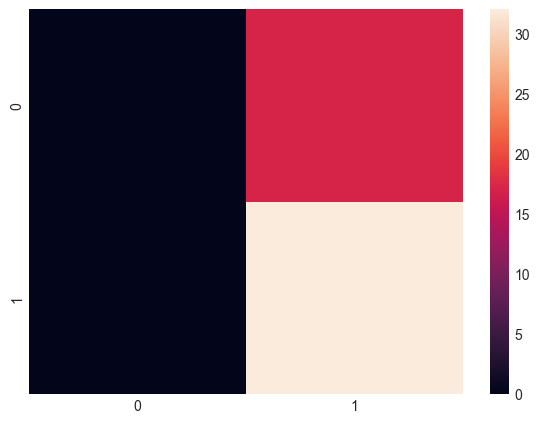

In [15]:
# create a heatmap based on confusion marix

sns.heatmap(cm_nb)

In [ ]:
#SNAS: to refer to sir's note on how sir's execute the data